# Analiza Danych Sprzedażowych

Ten notatnik służy do wczytania i wstępnej wizualizacji danych.

        date  sales
0 2023-01-01    100
1 2023-01-02    120
2 2023-01-03    115
3 2023-01-04    130
4 2023-01-05    145


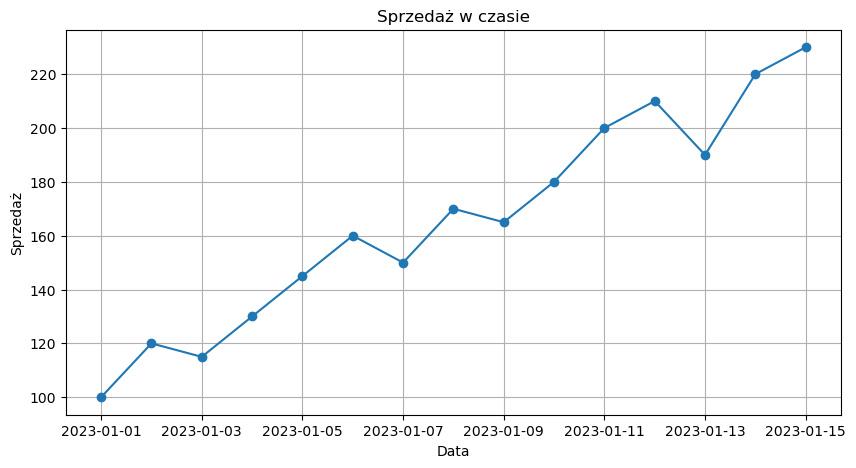

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Wczytanie danych
df = pd.read_csv('../data/sample_sales.csv', parse_dates=['date'])

# Podgląd danych
print(df.head())

# Prosty wykres
plt.figure(figsize=(10, 5))
plt.plot(df['date'], df['sales'], marker='o')
plt.title('Sprzedaż w czasie')
plt.xlabel('Data')
plt.ylabel('Sprzedaż')
plt.grid(True)
plt.show()

## Budowa prostego modelu predykcyjnego
Teraz użyjemy regresji liniowej, aby nauczyć się trendu na podstawie danych historycznych i przewidzieć sprzedaż na kolejne dni.
Konwertujemy datę na dni roku (cecha numeryczna), trenujemy model i rysujemy wykres z prognozą.

Model wytrenowany! Współczynnik R2: 0.9549

Prognoza na kolejne 5 dni:
        date  sales_predicted
0 2023-01-16       234.952381
1 2023-01-17       243.613095
2 2023-01-18       252.273810
3 2023-01-19       260.934524
4 2023-01-20       269.595238


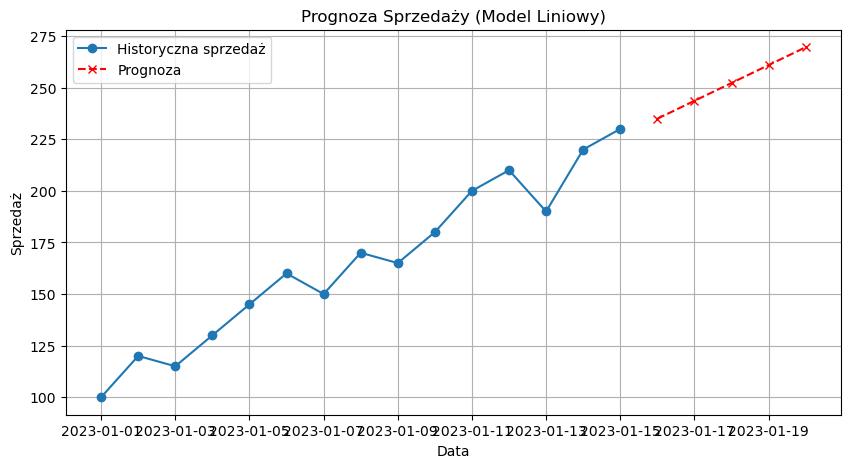

In [4]:
from sklearn.linear_model import LinearRegression
import numpy as np

# 1. Inżynieria Cech (Feature Engineering)
# Zamieniamy datę na liczby, które model zrozumie
df['day_of_year'] = df['date'].dt.dayofyear
df['year'] = df['date'].dt.year

# Przygotowanie danych do modelu
X = df[['day_of_year', 'year']]
y = df['sales']

# 2. Trenowanie Modelu
model = LinearRegression()
model.fit(X, y)

print(f"Model wytrenowany! Współczynnik R2: {model.score(X, y):.4f}")

# 3. Predykcja na przyszłość (np. kolejne 5 dni)
last_date = df['date'].max()
future_dates = [last_date + pd.Timedelta(days=x) for x in range(1, 6)]
future_df = pd.DataFrame({'date': future_dates})
future_df['day_of_year'] = future_df['date'].dt.dayofyear
future_df['year'] = future_df['date'].dt.year

# Wykonujemy predykcję
predictions = model.predict(future_df[['day_of_year', 'year']])
future_df['sales_predicted'] = predictions

print("\nPrognoza na kolejne 5 dni:")
print(future_df[['date', 'sales_predicted']])

# 4. Wizualizacja
plt.figure(figsize=(10, 5))
plt.plot(df['date'], df['sales'], label='Historyczna sprzedaż', marker='o')
plt.plot(future_df['date'], future_df['sales_predicted'], label='Prognoza', linestyle='--', marker='x', color='red')
plt.title('Prognoza Sprzedaży (Model Liniowy)')
plt.xlabel('Data')
plt.ylabel('Sprzedaż')
plt.legend()
plt.grid(True)
plt.show()